# Analisis Data Sekolah Provinsi Jawa Timur (Versi 2.0 - Update Data Kemendikbud 2026)

Notebook ini berisi analisis data jumlah sekolah di Jawa Timur berdasarkan data terbaru dari **Dapodik (Kementerian Pendidikan, Kebudayaan, Riset, dan Teknologi)**.
Analisis difokuskan pada distribusi fasilitas pendidikan (Negeri dan Swasta) serta pemetaan spasial (Kabupaten vs Kota).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 1. Data Loading dan Preprocessing
Memuat file Excel data sekolah Negeri dan Swasta terbaru, kemudian menggabungkannya.


In [2]:
# Memuat data dari file Excel (baris ke-5 adalah header)
df_negeri = pd.read_excel('../data/Data Induk Satuan Pendidikan  - JUMLAH Provinsi 050000 - 1 - ASC - 03 Agustus 2026.xlsx', header=4)
df_swasta = pd.read_excel('../data/Data Induk Satuan Pendidikan  - JUMLAH Provinsi 050000 - 2 - ASC - 03 Agustus 2026.xlsx', header=4)

# Menghapus baris kosong/Grand Total jika ada
df_negeri = df_negeri.dropna(subset=['Nama Wilayah']).copy()
df_swasta = df_swasta.dropna(subset=['Nama Wilayah']).copy()

# Filter out "Jumlah Satuan Pendidikan" or invalid rows
df_negeri = df_negeri[~df_negeri['Nama Wilayah'].str.contains('Total', na=False)]
df_swasta = df_swasta[~df_swasta['Nama Wilayah'].str.contains('Total', na=False)]

def clean_region_name(name):
    name = str(name).strip()
    return name.title().replace('Kab.', 'Kab.').replace('Kota', 'Kota')

df_negeri['Wilayah'] = df_negeri['Nama Wilayah'].apply(clean_region_name)
df_swasta['Wilayah'] = df_swasta['Nama Wilayah'].apply(clean_region_name)

df_negeri['Tipe_Wilayah'] = df_negeri['Wilayah'].apply(lambda x: 'Kota' if 'Kota' in x else 'Kabupaten')
df_swasta['Tipe_Wilayah'] = df_swasta['Wilayah'].apply(lambda x: 'Kota' if 'Kota' in x else 'Kabupaten')

# Merge kedua dataset untuk perbandingan Negeri vs Swasta
kolom_merge = ['Wilayah', 'Tipe_Wilayah', 'Total', 'TK Sederajat', 'KB Sederajat', 'TPA', 'SPS', 'SD Sederajat', 'SMP Sederajat', 'SMA Sederajat', 'SMK Sederajat']
df_negeri_merge = df_negeri[kolom_merge].add_suffix('_Negeri').rename(columns={'Wilayah_Negeri': 'Wilayah', 'Tipe_Wilayah_Negeri': 'Tipe_Wilayah'})
df_swasta_merge = df_swasta[kolom_merge].add_suffix('_Swasta').rename(columns={'Wilayah_Swasta': 'Wilayah', 'Tipe_Wilayah_Swasta': 'Tipe_Wilayah'})

df_merge = pd.merge(df_negeri_merge, df_swasta_merge, on=['Wilayah', 'Tipe_Wilayah'], how='outer').fillna(0)
df_merge['Total_Keseluruhan'] = df_merge['Total_Negeri'] + df_merge['Total_Swasta']

# Buat kolom total gabungan untuk setiap jenjang
for level in ['TK Sederajat', 'KB Sederajat', 'TPA', 'SPS', 'SD Sederajat', 'SMP Sederajat', 'SMA Sederajat', 'SMK Sederajat']:
    df_merge[f'{level}_Total'] = df_merge[f'{level}_Negeri'] + df_merge[f'{level}_Swasta']

# Sort dataframe alphabetically by Wilayah
df_merge = df_merge.sort_values('Wilayah').reset_index(drop=True)

print("Data berhasil digabung! Menampilkan 5 baris pertama:")
display(df_merge.head())


Data berhasil digabung! Menampilkan 5 baris pertama:


,Wilayah,Tipe_Wilayah,Total_Negeri,TK Sederajat_Negeri,KB Sederajat_Negeri,TPA_Negeri,SPS_Negeri,SD Sederajat_Negeri,SMP Sederajat_Negeri,SMA Sederajat_Negeri,...,SMK Sederajat_Swasta,Total_Keseluruhan,TK Sederajat_Total,KB Sederajat_Total,TPA_Total,SPS_Total,SD Sederajat_Total,SMP Sederajat_Total,SMA Sederajat_Total,SMK Sederajat_Total
0,Kab. Bangkalan,Kabupaten,707.0,11.0,0.0,0.0,0.0,617.0,57.0,11.0,...,61.0,2608.0,717.0,263.0,9.0,69.0,829.0,412.0,146.0,71.0
1,Kab. Banyuwangi,Kabupaten,870.0,2.0,0.0,0.0,0.0,747.0,86.0,23.0,...,80.0,3101.0,954.0,249.0,6.0,4.0,1070.0,368.0,145.0,89.0
2,Kab. Blitar,Kabupaten,727.0,2.0,0.0,0.0,0.0,648.0,60.0,10.0,...,27.0,2455.0,921.0,294.0,10.0,9.0,878.0,178.0,51.0,33.0
3,Kab. Bojonegoro,Kabupaten,811.0,4.0,0.0,0.0,0.0,695.0,60.0,26.0,...,42.0,3667.0,947.0,585.0,13.0,597.0,1006.0,262.0,122.0,61.0
4,Kab. Bondowoso,Kabupaten,540.0,9.0,0.0,0.0,0.0,444.0,52.0,11.0,...,42.0,2426.0,560.0,701.0,3.0,27.0,590.0,255.0,100.0,60.0


## 2. Analisis Distribusi Total Sekolah (Negeri vs Swasta)
Melihat Top 10 wilayah dengan infrastruktur pendidikan terbesar.


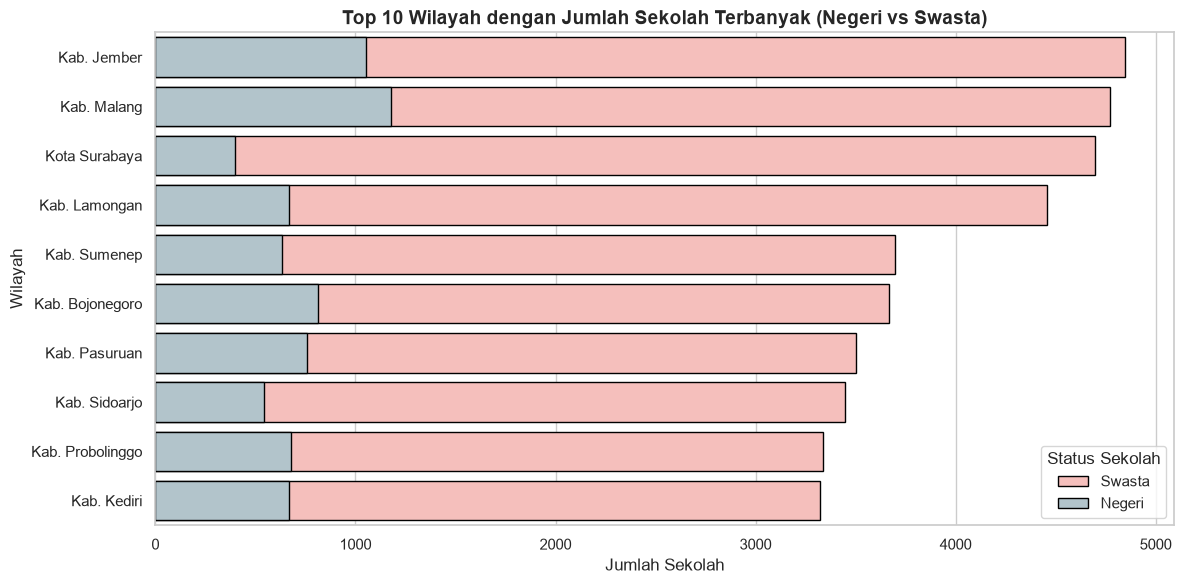

In [3]:
top_10 = df_merge.nlargest(10, 'Total_Keseluruhan')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Total_Keseluruhan', y='Wilayah', color='#FFB7B2', edgecolor='black', linewidth=1, label='Swasta')
sns.barplot(data=top_10, x='Total_Negeri', y='Wilayah', color='#AEC6CF', edgecolor='black', linewidth=1, label='Negeri')
plt.title('Top 10 Wilayah dengan Jumlah Sekolah Terbanyak (Negeri vs Swasta)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Sekolah', fontsize=12)
plt.ylabel('Wilayah', fontsize=12)
plt.legend(title='Status Sekolah', loc='lower right')
plt.tight_layout()
plt.show()


## 3. Komparasi Kota vs Kabupaten
Perbedaan agregat total sekolah berdasarkan tipe wilayah administratif.


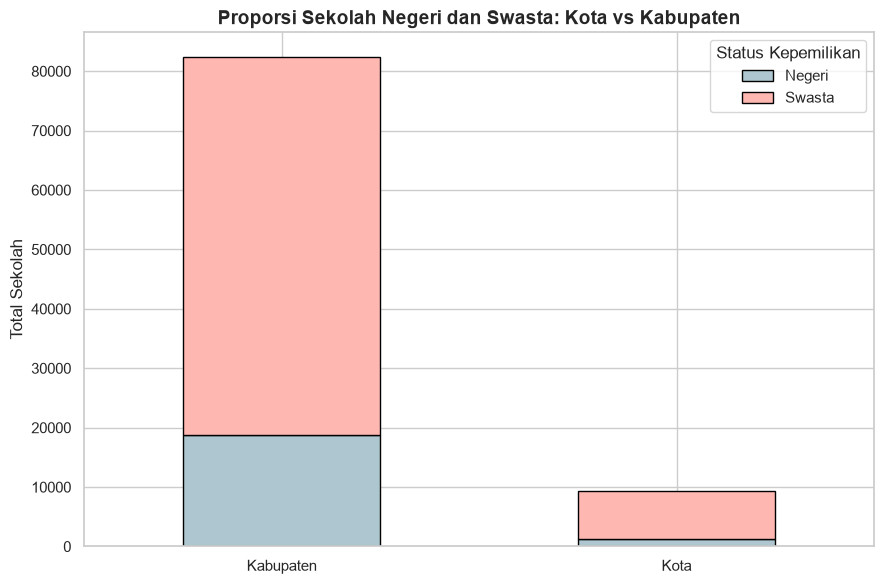

In [4]:
komparasi = df_merge.groupby('Tipe_Wilayah')[['Total_Negeri', 'Total_Swasta']].sum().reset_index()

komparasi.set_index('Tipe_Wilayah').plot(kind='bar', stacked=True, color=['#AEC6CF', '#FFB7B2'], edgecolor='black', linewidth=1, figsize=(9, 6))
plt.title('Proporsi Sekolah Negeri dan Swasta: Kota vs Kabupaten', fontsize=14, fontweight='bold')
plt.ylabel('Total Sekolah', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0, fontsize=11)
plt.legend(['Negeri', 'Swasta'], title='Status Kepemilikan', loc='upper right')
plt.tight_layout()
plt.show()


## 4. Analisis Geospasial Kepadatan Sekolah
### 4.1 Kepadatan Keseluruhan (Total)
Memetakan sebaran kepadatan total sekolah per wilayah menggunakan Plotly Mapbox.


In [5]:
# Koordinat presisi Kabupaten/Kota Jawa Timur
region_coordinates = {
    'Kota Surabaya': (-7.257, 112.750), 'Kota Malang': (-7.977, 112.635), 'Kota Kediri': (-7.811, 112.003),
    'Kota Mojokerto': (-7.474, 112.435), 'Kota Blitar': (-8.100, 112.181), 'Kota Pasuruan': (-7.638, 112.904),
    'Kota Probolinggo': (-7.755, 113.196), 'Kota Batu': (-7.879, 112.528), 'Kota Madiun': (-7.631, 111.531),
    'Kab. Gresik': (-7.168, 112.653), 'Kab. Sidoarjo': (-7.435, 112.722), 'Kab. Jember': (-8.171, 113.703),
    'Kab. Lamongan': (-7.113, 112.414), 'Kab. Bojonegoro': (-7.154, 111.882), 'Kab. Tuban': (-6.897, 111.964),
    'Kab. Jombang': (-7.546, 112.234), 'Kab. Nganjuk': (-7.605, 111.904), 'Kab. Magetan': (-7.647, 111.350),
    'Kab. Ponorogo': (-7.874, 111.462), 'Kab. Pacitan': (-8.205, 111.092), 'Kab. Trenggalek': (-8.051, 111.708),
    'Kab. Tulungagung': (-8.064, 111.902), 'Kab. Lumajang': (-8.133, 113.225), 'Kab. Bondowoso': (-7.913, 113.822),
    'Kab. Situbondo': (-7.706, 114.010), 'Kab. Banyuwangi': (-8.219, 114.369), 'Kab. Pamekasan': (-7.156, 113.476),
    'Kab. Sampang': (-7.047, 113.239), 'Kab. Sumenep': (-7.017, 113.854), 'Kab. Bangkalan': (-7.045, 112.739),
    'Kab. Kediri': (-7.848, 112.018), 'Kab. Malang': (-8.026, 112.652), 'Kab. Pasuruan': (-7.745, 112.907),
    'Kab. Probolinggo': (-7.724, 113.215), 'Kab. Mojokerto': (-7.553, 112.434), 'Kab. Blitar': (-8.097, 112.165)
}

# Mapping coordinates ke dataframe
df_merge['latitude'] = df_merge['Wilayah'].map(lambda x: region_coordinates.get(x, (None, None))[0])
df_merge['longitude'] = df_merge['Wilayah'].map(lambda x: region_coordinates.get(x, (None, None))[1])
df_viz = df_merge.dropna(subset=['latitude'])

# Hitung ukuran bubble proporsional
def get_bubble(series, min_s=10, max_s=35):
    if series.max() == series.min(): return [min_s] * len(series)
    return min_s + (series - series.min()) / (series.max() - series.min()) * (max_s - min_s)

df_viz['b_tot'] = get_bubble(df_viz['Total_Keseluruhan'])
df_viz['b_neg'] = get_bubble(df_viz['Total_Negeri'])
df_viz['b_swa'] = get_bubble(df_viz['Total_Swasta'])

# Pisahkan data untuk Kabupaten dan Kota
df_kab = df_viz[df_viz['Tipe_Wilayah'] == 'Kabupaten'].copy()
df_kota = df_viz[df_viz['Tipe_Wilayah'] == 'Kota'].copy()

fig = go.Figure()

# Kabupaten = Red, Kota = Navy (High Contrast)
fig.add_trace(go.Scattermapbox(
    lat=df_kab['latitude'], lon=df_kab['longitude'], mode='markers',
    marker=dict(size=df_kab['b_tot'], color='#e63946', opacity=0.7),
    text=[f"<b>{w}</b><br>Total: {int(t)}<br>Tipe: Kabupaten" for w, t in zip(df_kab['Wilayah'], df_kab['Total_Keseluruhan'])],
    hovertemplate="%{text}<extra></extra>", name='Total (Kabupaten)'
))

fig.add_trace(go.Scattermapbox(
    lat=df_kota['latitude'], lon=df_kota['longitude'], mode='markers',
    marker=dict(size=df_kota['b_tot'], color='#1d3557', opacity=0.7),
    text=[f"<b>{w}</b><br>Total: {int(t)}<br>Tipe: Kota" for w, t in zip(df_kota['Wilayah'], df_kota['Total_Keseluruhan'])],
    hovertemplate="%{text}<extra></extra>", name='Total (Kota)'
))

fig.update_layout(
    mapbox=dict(style='open-street-map', center=dict(lat=-7.8, lon=112.5), zoom=6.5),
    height=600, width=900,
    title_text="<b>Peta Kepadatan Sekolah Keseluruhan (Total)</b>",
    title_x=0.5,
    margin={"r":10,"t":70,"l":10,"b":10},
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5, title="Legenda:")
)
fig.show()


### 4.2 Kepadatan Fasilitas Negeri


In [6]:
fig2 = go.Figure()

# Kabupaten = Dark Red, Kota = Dark Blue (High Contrast)
fig2.add_trace(go.Scattermapbox(
    lat=df_kab['latitude'], lon=df_kab['longitude'], mode='markers',
    marker=dict(size=df_kab['b_neg'], color='#d62828', opacity=0.7),
    text=[f"<b>{w}</b><br>Negeri: {int(t)}" for w, t in zip(df_kab['Wilayah'], df_kab['Total_Negeri'])],
    hovertemplate="%{text}<extra></extra>", name='Negeri (Kabupaten)'
))

fig2.add_trace(go.Scattermapbox(
    lat=df_kota['latitude'], lon=df_kota['longitude'], mode='markers',
    marker=dict(size=df_kota['b_neg'], color='#003049', opacity=0.7),
    text=[f"<b>{w}</b><br>Negeri: {int(t)}" for w, t in zip(df_kota['Wilayah'], df_kota['Total_Negeri'])],
    hovertemplate="%{text}<extra></extra>", name='Negeri (Kota)'
))

fig2.update_layout(
    mapbox=dict(style='open-street-map', center=dict(lat=-7.8, lon=112.5), zoom=6.5),
    height=600, width=900,
    title_text="<b>Peta Kepadatan Fasilitas Sekolah Negeri</b>",
    title_x=0.5,
    margin={"r":10,"t":70,"l":10,"b":10},
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5, title="Legenda:")
)
fig2.show()


### 4.3 Kepadatan Fasilitas Swasta


In [7]:
fig3 = go.Figure()

# Kabupaten = Orange, Kota = Purple (High Contrast)
fig3.add_trace(go.Scattermapbox(
    lat=df_kab['latitude'], lon=df_kab['longitude'], mode='markers',
    marker=dict(size=df_kab['b_swa'], color='#f77f00', opacity=0.7),
    text=[f"<b>{w}</b><br>Swasta: {int(t)}" for w, t in zip(df_kab['Wilayah'], df_kab['Total_Swasta'])],
    hovertemplate="%{text}<extra></extra>", name='Swasta (Kabupaten)'
))

fig3.add_trace(go.Scattermapbox(
    lat=df_kota['latitude'], lon=df_kota['longitude'], mode='markers',
    marker=dict(size=df_kota['b_swa'], color='#5a189a', opacity=0.7),
    text=[f"<b>{w}</b><br>Swasta: {int(t)}" for w, t in zip(df_kota['Wilayah'], df_kota['Total_Swasta'])],
    hovertemplate="%{text}<extra></extra>", name='Swasta (Kota)'
))

fig3.update_layout(
    mapbox=dict(style='open-street-map', center=dict(lat=-7.8, lon=112.5), zoom=6.5),
    height=600, width=900,
    title_text="<b>Peta Kepadatan Fasilitas Sekolah Swasta</b>",
    title_x=0.5,
    margin={"r":10,"t":70,"l":10,"b":10},
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5, title="Legenda:")
)
fig3.show()


## 5. Piramida Tingkat Pendidikan
Perbandingan jumlah fasilitas SD, SMP, SMA, dan SMK secara keseluruhan di Jawa Timur.


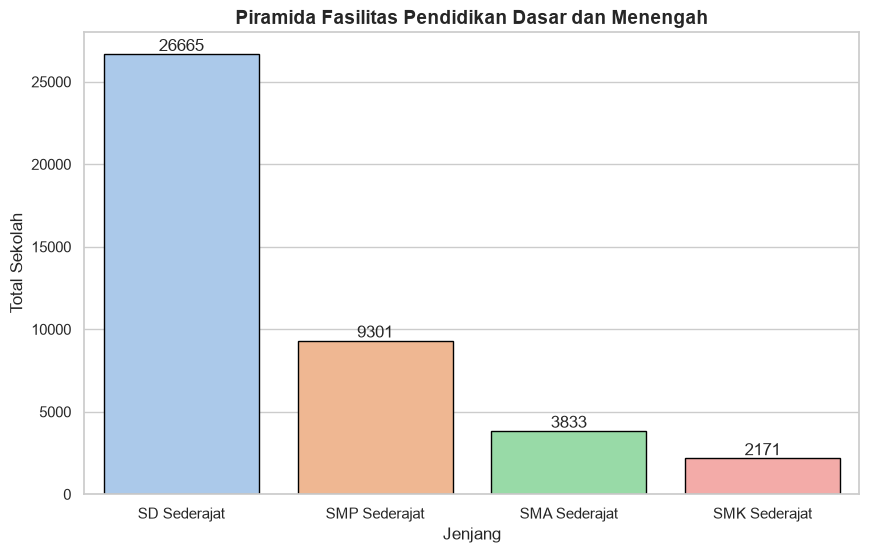

In [8]:
levels = ['SD Sederajat_Total', 'SMP Sederajat_Total', 'SMA Sederajat_Total', 'SMK Sederajat_Total']
totals = df_merge[levels].sum().reset_index()
totals.columns = ['Jenjang', 'Jumlah']
totals['Jenjang'] = totals['Jenjang'].str.replace('_Total', '')

plt.figure(figsize=(10, 6))
sns.barplot(data=totals, x='Jenjang', y='Jumlah', palette='pastel', edgecolor='black', linewidth=1)
plt.title('Piramida Fasilitas Pendidikan Dasar dan Menengah', fontsize=14, fontweight='bold')
plt.ylabel('Total Sekolah')
for i, v in enumerate(totals['Jumlah']):
    plt.text(i, v + 200, str(int(v)), ha='center')
plt.show()


## 6. Fokus Vokasi (SMA vs SMK)
Komparasi jumlah SMA vs SMK, dibedakan antara sekolah Negeri dan Swasta.


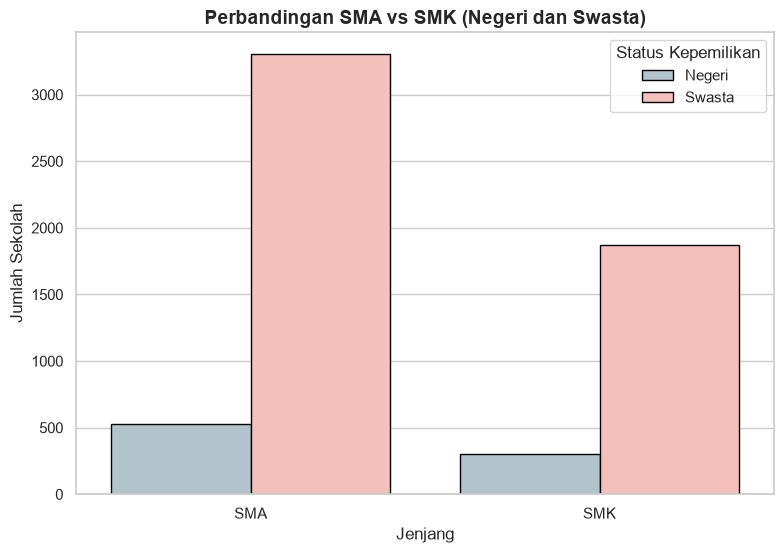

In [9]:
vokasi_data = {
    'Jenjang': ['SMA', 'SMA', 'SMK', 'SMK'],
    'Status': ['Negeri', 'Swasta', 'Negeri', 'Swasta'],
    'Jumlah': [
        df_merge['SMA Sederajat_Negeri'].sum(),
        df_merge['SMA Sederajat_Swasta'].sum(),
        df_merge['SMK Sederajat_Negeri'].sum(),
        df_merge['SMK Sederajat_Swasta'].sum()
    ]
}
df_vokasi = pd.DataFrame(vokasi_data)

plt.figure(figsize=(9, 6))
sns.barplot(data=df_vokasi, x='Jenjang', y='Jumlah', hue='Status', palette={'Negeri': '#AEC6CF', 'Swasta': '#FFB7B2'}, edgecolor='black', linewidth=1)
plt.title('Perbandingan SMA vs SMK (Negeri dan Swasta)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Sekolah')
plt.legend(title='Status Kepemilikan', loc='upper right')
plt.show()


## 7. Analisis Bottleneck Pendidikan (Rasio SD ke Lanjutan)
Menghitung rata-rata berapa banyak SMP dan SMA/SMK yang tersedia untuk setiap SD.


In [10]:
total_sd = df_merge['SD Sederajat_Total'].sum()
total_smp = df_merge['SMP Sederajat_Total'].sum()
total_sma_smk = df_merge['SMA Sederajat_Total'].sum() + df_merge['SMK Sederajat_Total'].sum()

print(f"Total SD: {int(total_sd):,}")
print(f"Total SMP: {int(total_smp):,}")
print(f"Total SMA/SMK: {int(total_sma_smk):,}")
print("-" * 30)
print(f"Rasio SD ke SMP: 1 SMP untuk setiap {total_sd/total_smp:.1f} SD")
print(f"Rasio SMP ke SMA/SMK: 1 SMA/SMK untuk setiap {total_smp/total_sma_smk:.1f} SMP")


Total SD: 26,665
Total SMP: 9,301
Total SMA/SMK: 6,004
------------------------------
Rasio SD ke SMP: 1 SMP untuk setiap 2.9 SD
Rasio SMP ke SMA/SMK: 1 SMA/SMK untuk setiap 1.5 SMP


## Kesimpulan Analisis 🏆
*   **Dominasi Swasta di Kota-Kota Besar:** Berdasarkan grafik perbandingan Kota vs Kabupaten, sekolah swasta cenderung sangat mendominasi di wilayah perkotaan.
*   **Peran Sentral Sekolah Negeri di Kabupaten:** Di area Kabupaten, sekolah negeri memegang peranan kunci secara kuantitas.
*   **Hotspot Infrastruktur Pendidikan:** Kabupaten Sidoarjo, Bojonegoro, dan Gresik menjadi *hotspot* jumlah infrastruktur pendidikan.
*   **Dominasi Swasta pada Sekolah Vokasi:** Sekolah vokasi (SMK) sangat didominasi oleh sektor swasta, mengindikasikan tingginya partisipasi masyarakat dalam pendidikan praktis.
*   **Bottleneck Pendidikan:** Rasio jumlah SD terhadap SMP dan SMA menunjukkan adanya penyusutan jumlah fasilitas secara signifikan (piramida mengerucut tajam), yang berarti persaingan masuk ke sekolah lanjutan jauh lebih ketat.
